In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from scipy import sparse
import scanpy as sc
import matplotlib.pyplot as plt
import os
import glob
import rpy2.robjects as ro
import shutil
import seaborn as sns  

from dotenv import load_dotenv; load_dotenv()

from utils import preprocessing
from utils import nebula_with_factors as nebula_utils

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ATTENTION: need for perpty of running jupternotbook
%matplotlib inline

PARALLEL_NEBULA_SCRIPT_PATH = os.getenv("PARALLEL_NEBULA_SCRIPT")

TISSUE = "Striatum" # Striatum, DFC,SN
TYPE_DEG = "baseline_nebula" #PCA_nebula, baseline_nebula, cNMF_nebula, gradient_score_nebula




if TISSUE == "Striatum":
    ADATA_PATH = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/{TISSUE}/{TISSUE}_combined_QC_mmc_ct-cured_zoned.h5ad"
elif (TISSUE == "DFC") | (TISSUE == "SN"):
    # no zones
    ADATA_PATH = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/{TISSUE}/{TISSUE}_combined_QC_mmc_ct-cured.h5ad"

# name of cell tyoe vauble annotaton to use in this analsys
CT_FOR_DEG_VARIABLE = "ct_for_deg" #"Group_name",  "spn_type"
# name of Sample varibale
SAMPLE_VARIABLE = "donor_id"
# variable to test if differtially epxresseda
CONTRAST_VARIABLE = "condition"
# Level of contrat varibale to use as baseline
CONTRAST_BASELINE = "Control"
# Level of contrat varibale to use as stimulated
CONTRAST_STIM = "XDP"

# Covariates to use for stat test
COVARIATES_FOR_DEG = ["age_of_death", "sex", "pct_counts_mt", "frac_intronic", "cohort",
                     #f"age_of_death:{CONTRAST_VARIABLE}"
                      ]
# libraru size col for  enbula
LIBRARY_SIZE_COL = "total_counts"

# # mitluple etst correction pvalue thr
# ALPHA_MULTIPLE_TEST = 0.05
# LOGFC_THR=0.1
# PVAL_THR=0.05

# Save folder
DEG_FOLDER =F"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/{TISSUE}/{TYPE_DEG}" # "/home/gdallagl/myworkdir/XDP/data/_old/nucseq_deg_pca_age" #F"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/{TISSUE}/{TYPE_DEG}"
os.makedirs(DEG_FOLDER, exist_ok=True)
DEG_FOLDER

'/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/baseline_nebula'

In [18]:
ct_forcNMF = {
    "Striatum": ["Matrix_D1", "Matrix_D2", "Patch_D1", "Patch_D2", "eMSN_D1D2", "eMSN_StrioMat", "eMSN_NUDAP","Oligodendrocyte", "Astrocyte", "Microglia"],
    "DFC": ["Oligodendrocyte", "Astrocyte", "Microglia"],
    "SN": ["Oligodendrocyte", "Astrocyte", "Microglia"],
}

"""
1) request access to UGER macosko folder
2) ssh in UGER
	$ssh gdallagl@login02.broadinstitute.org
3) lunch tmudx
	$tmux
4) type
	$use UGER
5) request interactive node
	$/broad/software/scripts/ish -l h_vmem=10g -pe smp 4 -binding linear:4 -l h_rt=12:00:00 -l os='RedHat7'
6) cd your working folder
	$ cd /broad/macosko/gdallagl/cNMF
7) type
	$use UGER
8) run scirpt to open jupyer on website
	$./start_jupyter_cNMF.sh 
	*) paste link into browser


first run once the cell n order to egenrate the hlahy datset --> then upload on uger


to copy adata to google bucket (on VM terminal)

    TISSUE="DFC"
    for cell_type in "Matrix_D1" "Matrix_D2" "Patch_D1" "Patch_D2" "eMSN_D1D2" "eMSN_StrioMat" "eMSN_NUDAP" "Oligodendrocyte" "Astrocyte" "Microglia"; do
        echo "Copying $cell_type..."
        gsutil cp /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/$TISSUE/cNMF_nebula/$cell_type/healthy_cNMF.h5ad \
            gs://macosko_data/gdallagl/NucSeq/healthy_adata_for_cNMF/$TISSUE/$cell_type/healthy_cNMF.h5ad
    done

to copy form google bucket to auger (on UGER terminal)

    use UGER
    ish #alias to reaeust small ndoe
    use Google-Cloud-SDK

    TISSUE="DFC"
    for cell_type in "Matrix_D1" "Matrix_D2" "Patch_D1" "Patch_D2" "eMSN_D1D2" "eMSN_StrioMat" "eMSN_NUDAP" "Oligodendrocyte" "Astrocyte" "Microglia"; do
        echo "Copying $cell_type..."
        mkdir -p /broad/macosko/gdallagl/cNMF/NucSeq/$TISSUE/$cell_type/input
        gsutil cp gs://macosko_data/gdallagl/NucSeq/healthy_adata_for_cNMF/$TISSUE/$cell_type/healthy_cNMF.h5ad \
            /broad/macosko/gdallagl/cNMF/NucSeq/$TISSUE/$cell_type/input/
    done

Run facotrization on UGER

to copy from UGER to google bucket (on UGER terminal)

    use Google-Cloud-SDK
    TISSUE="DFC"
    for cell_type in Matrix_D1 Matrix_D2 Patch_D1 Patch_D2 eMSN_D1D2 eMSN_StrioMat eMSN_NUDAP Oligodendrocyte Astrocyte Microglia; do
        echo "Copying $cell_type..."
        gsutil -m cp -r \
            /broad/macosko/gdallagl/cNMF/NucSeq/$TISSUE/$cell_type/output/final_results/* \
            gs://macosko_data/gdallagl/NucSeq/healthy_adata_for_cNMF/$TISSUE/$cell_type/cNMF_run_healthy/
    done
    

to copy from google bucket to local (on VM terminal)

    TISSUE="DFC"
    for cell_type in "Matrix_D1" "Matrix_D2" "Patch_D1" "Patch_D2" "eMSN_D1D2" "eMSN_StrioMat" "eMSN_NUDAP" "Oligodendrocyte" "Astrocyte" "Microglia"; do
        echo "Copying $cell_type..."
        mkdir -p /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/$TISSUE/cNMF_nebula/$cell_type/cNMF_run_healthy
        gsutil cp -r gs://macosko_data/gdallagl/NucSeq/healthy_adata_for_cNMF/$TISSUE/$cell_type/cNMF_run_healthy/* \
            /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/$TISSUE/cNMF_nebula/$cell_type/cNMF_run_healthy/
    done

"""

'\n1) request access to UGER macosko folder\n2) ssh in UGER\n\t$ssh gdallagl@login02.broadinstitute.org\n3) lunch tmudx\n\t$tmux\n4) type\n\t$use UGER\n5) request interactive node\n\t$/broad/software/scripts/ish -l h_vmem=10g -pe smp 4 -binding linear:4 -l h_rt=12:00:00 -l os=\'RedHat7\'\n6) cd your working folder\n\t$ cd /broad/macosko/gdallagl/cNMF\n7) type\n\t$use UGER\n8) run scirpt to open jupyer on website\n\t$./start_jupyter_cNMF.sh \n\t*) paste link into browser\n\n\nfirst run once the cell n order to egenrate the hlahy datset --> then upload on uger\n\n\nto copy adata to google bucket (on VM terminal)\n\n    TISSUE="DFC"\n    for cell_type in "Matrix_D1" "Matrix_D2" "Patch_D1" "Patch_D2" "eMSN_D1D2" "eMSN_StrioMat" "eMSN_NUDAP" "Oligodendrocyte" "Astrocyte" "Microglia"; do\n        echo "Copying $cell_type..."\n        gsutil cp /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/$TISSUE/cNMF_nebula/$cell_type/healthy_cNMF.h5ad             gs://macosko_data/gdallagl/NucSeq/health

# Read adata

In [2]:
print("Loading adata... \ntissue:", TISSUE, "\ntype of DEG:", TYPE_DEG)
adata = sc.read_h5ad(ADATA_PATH)#, backed="r")
adata.obs.columns

###########################
#ATTENTION: use genenames for DEG
adata.var.index = adata.var["gene_symbol"]
###########################

###########################
#ATTENTION: remove "bad cell" ypes
adata = adata[~adata.obs["ct_for_deg"].str.startswith("-"), :].copy()
###########################

###########################
#ATTENTION: be sure cell types have no space
adata.obs[CT_FOR_DEG_VARIABLE] = adata.obs[CT_FOR_DEG_VARIABLE].str.replace(" ", "_")
###########################

###########################
#ATTENTION: remove bad quality samples
adata = adata[~adata.obs[CONTRAST_VARIABLE].isna()].copy()
###########################

Loading adata... 
tissue: Striatum 
type of DEG: baseline_nebula


In [3]:
# ATTENTION: just one mix d1 and d2 and run anasys
adata =  adata[adata.obs[CT_FOR_DEG_VARIABLE].isin(["Matrix_D1", "Matrix_D2", "Patch_D1", "Patch_D2"])].copy()
adata.obs[CT_FOR_DEG_VARIABLE].replace({"Matrix_D1": "Matrix", "Matrix_D2": "Matrix", "Patch_D1": "Patch", "Patch_D2": "Patch"}, inplace=True)

adata.obs[CT_FOR_DEG_VARIABLE].value_counts()

/tmp/ipykernel_2990247/2225761323.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adata.obs[CT_FOR_DEG_VARIABLE].replace({"Matrix_D1": "Matrix", "Matrix_D2": "Matrix", "Patch_D1": "Patch", "Patch_D2": "Patch"}, inplace=True)


ct_for_deg
Matrix    22782
Patch      7269
Name: count, dtype: int64

In [4]:
# RUN_ON_ZONES = False # if False, will run on ct

# if RUN_ON_ZONES:

#     ZONE_CT = "Astrocyte" #Astrocyte, Matrix_D1

#     # Each cell type has a better zonation level
#     if ZONE_CT in ["Matrix_D1", "Matrix_D2"]:
#         ZONE_VARIABLE = "zone_6" 
#     if ZONE_CT in ["Patch_D1", "Patch_D2", "eMSN_D1D2", "Astrocyte"]:
#         ZONE_VARIABLE = "zone_4"

#     adata = adata[
#         (adata.obs["ct_for_deg"] == ZONE_CT) & # only QC cells tat are matrix
#         (adata.obs[ZONE_VARIABLE].notna()) # only cells with zone annotation
#     ].to_memory().copy()
    
#     # chnage zone to be treated as ct
#     CT_FOR_DEG_VARIABLE = ZONE_VARIABLE

#     print(adata)
#     print(adata.obs.groupby([ZONE_VARIABLE, CONTRAST_VARIABLE]).size())

# Define gradient genes

In [21]:
GRAD_THR=0.1

df_grad = pd.read_csv("/home/gdallagl/myworkdir/XDP/utils/dorsal_ventral_gradient/exp_by_spline_combined.csv")

grad_genes = df_grad[
    (np.abs(df_grad.mean_spearman)>= GRAD_THR) & 
    (df_grad.combined_p <= 0.05) &
    (df_grad.mean_spearman.notna()) 
    ]["gene"].tolist()
print(len(grad_genes))

df_grad["is_gradient_gene"] = df_grad["gene"].isin(grad_genes)
print(df_grad["is_gradient_gene"].sum())
df_grad = df_grad.set_index("gene")[["mean_spearman", "is_gradient_gene"]]
df_grad

1241
1241


,mean_spearman,is_gradient_gene
gene,,
A1BG,-0.002360,False
A1BG-AS1,-0.007881,False
A1CF,0.007398,False
A2M,-0.002144,False
A2M-AS1,-0.000389,False
...,...,...
ENSG00000277836,NaN,False
ENSG00000278633,NaN,False
ENSG00000276017,-0.008289,False


# Calculate gradient score

In [6]:
# def calc_gradient_score(adata, df_grad, csv_save_path, col_corr="mean_spearman"):

#     print("ATTENTION: adata.X must be raw.")
#     print("ATTENTION: df_grad must have ONLY gradient genes and gene names as index.")

#     # Normalise
#     sc.pp.normalize_total(adata, target_sum=1e4)
#     sc.pp.log1p(adata)

#     # Calculate collim genes
#     common_genes = adata.var_names.intersection(df_grad.index)

#     # Subset to common genes
#     import scipy.sparse as sp
#     df_grad = df_grad.loc[common_genes]
#     X_grad_genes = adata[:, common_genes].X  # (n_cells × n_genes)
#     X_grad_genes = X_grad_genes.toarray() if sp.issparse(X_grad_genes) else np.asarray(X_grad_genes)


#     # calculate score
#     # more dorsal genes --> higher score
#     adata.obs["gradient_score"] = - X_grad_genes @ df_grad[col_corr].values

#     assert not adata.obs['gradient_score'].isna().any(), "Some cells have no gradient scores!"

#     # save df
#     df_scores = adata.obs[["gradient_score"]]
#     df_scores.to_csv(csv_save_path)


In [7]:
# # define genes for grad

# save_csv_path = f"{os.path.dirname(ADATA_PATH)}/gradient_scores.csv"

# if not os.path.exists(save_csv_path):

#     adata.X = adata.layers["counts"].copy()  # use raw counts for score calculation
#     df_grad_significant = df_grad[df_grad["is_gradient_gene"]]
#     calc_gradient_score(adata, df_grad_significant, save_csv_path)

# else:
#     df_scores = pd.read_csv(save_csv_path, index_col=0)
#     adata.obs = adata.obs.merge(df_scores, how="left", left_index=True, right_index=True, validate="one_to_one")
#     # Check that all cells have scores
#     assert not adata.obs['gradient_score'].isna().any(), "Some cells have no gradient scores!"

In [8]:
# sns.histplot(data=adata.obs, x="gradient_score", hue=CONTRAST_VARIABLE, bins=50); plt.show()
# # sns.histplot(data=adata.obs[adata.obs["broad_original_cell_type"] == "Striatum_Neuron"], x="gradient_score", hue=CONTRAST_VARIABLE, bins=50); plt.show()
# # sns.histplot(data= adata.obs[adata.obs["ct_for_deg"] == "Matrix"], x="gradient_score", hue=CONTRAST_VARIABLE, bins=50); plt.show()
# # sns.histplot(data= adata.obs[(adata.obs["Group_name"].isin(["STRd D1 Matrix MSN", "STRv D1 MSN"])) & (adata.obs["ct_for_deg"] == "Matrix")], x="gradient_score", hue=CONTRAST_VARIABLE, bins=50); plt.show()

In [9]:
# # Compare mean gradient score per donor
# if RUN_ON_ZONES:

#     sns.histplot(data=adata.obs, x="gradient_score", hue=CONTRAST_VARIABLE, bins=50); plt.show()

#     donor_zone_mean = (
#         adata.obs.groupby([SAMPLE_VARIABLE, CONTRAST_VARIABLE, "zone"])["gradient_score"]
#         .mean()
#         .reset_index()
#     )

#     sns.boxplot(data=donor_zone_mean, x="zone", y="gradient_score", hue=CONTRAST_VARIABLE)

# Define functions

## Nebula Gene Filtering & PCA Stopping Criteria

### Gene Filtering
1. Drop donors with < `min_cells_per_sample` cells.  
2. Keep genes expressed in ≥ `n_donors × min_cells_per_sample` cells.  
3. Keep genes with ≥ `min_counts` total counts.  
4. Skip analysis if:
   - Any condition has < `MIN_SAMPLES_PER_CONDITION` donors.  
   - Remaining genes ≤ `MIN_NUMBER_GENES_PER_ANALYSIS`.  

# Run for all ct

In [22]:
# sc.pl.umap(adata_ct, color=[CONTRAST_VARIABLE, "Group_name", "vireo_prob_doublet"], palette="tab20")
# pcs = [c for c in adata_ct.obs.columns if c.startswith("PC_")]
# DEG.check_corr_cov_in_design(adata_ct, vars_in_formula=[CONTRAST_VARIABLE, *pcs, *COVARIATES_FOR_DEG], corr_thr=0.7, split=" + ")

sorted(adata.obs[CT_FOR_DEG_VARIABLE].unique().tolist())[:]

['Matrix', 'Patch']



######################
 Matrix 
######################

True
/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/baseline_nebula/Matrix/tmp_Striatum_combined_QC_mmc_ct-cured_zoned_Matrix_for_nebula.qs
True
ATTENTION: .X must be raw!
Retained donors : 47
Filtered genes  : 38601 -> 20794 (min_cells=470, min_counts=50)
Running Factor calculation on Healthy...


/home/gdallagl/myworkdir/XDP/utils/nebula_with_factors.py:462: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


Running Factor calculation on Diseased...
Saving h5ad file...
adata intact: 22782 cells, 20794 genes
ATTENTION: Dropping 0 cells with NaN covariates: []


... storing 'ct_for_deg' as categorical


~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + total_counts


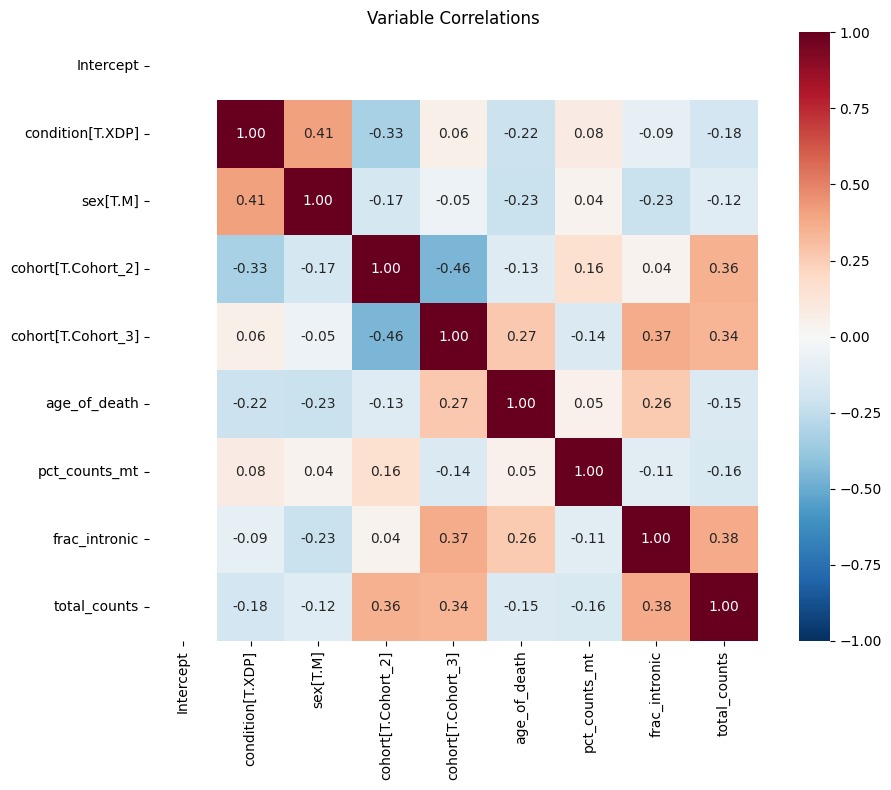

             variable         VIF
0           Intercept  419.778518
4  cohort[T.Cohort_3]    2.454872
3  cohort[T.Cohort_2]    2.418015
8        total_counts    2.315320
5        age_of_death    1.440252
7       frac_intronic    1.417171
1    condition[T.XDP]    1.415482
2            sex[T.M]    1.282487
6       pct_counts_mt    1.127888

binary identifiability test. False
Saving qs file...
	Saving files for R coversion...
	Building R obj...

Setting condition reference level to: Control
Levels: Control XDP 
[1] "Creating Seurat object..."


2026-05-20 12:50:13 | [WARNING] R callback write-console: Warning:  
2026-05-20 12:50:13 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/baseline_nebula/Matrix/tmp_Striatum_combined_QC_mmc_ct-cured_zoned_Matrix_for_nebula.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/baseline_nebula/Matrix/tmp_Striatum_combined_QC_mmc_ct-cured_zoned_Matrix_for_nebula.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/baseline_nebula/Matrix/tmp_Striatum_combined_QC_mmc_ct-cured_zoned_Matrix_for_nebula.qs

/home/gdallagl/myworkdir/XDP/utils/nebula_with_factors.py:462: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


Running Factor calculation on Diseased...
Saving h5ad file...
adata intact: 7263 cells, 16824 genes
ATTENTION: Dropping 0 cells with NaN covariates: []


... storing 'ct_for_deg' as categorical


~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + total_counts


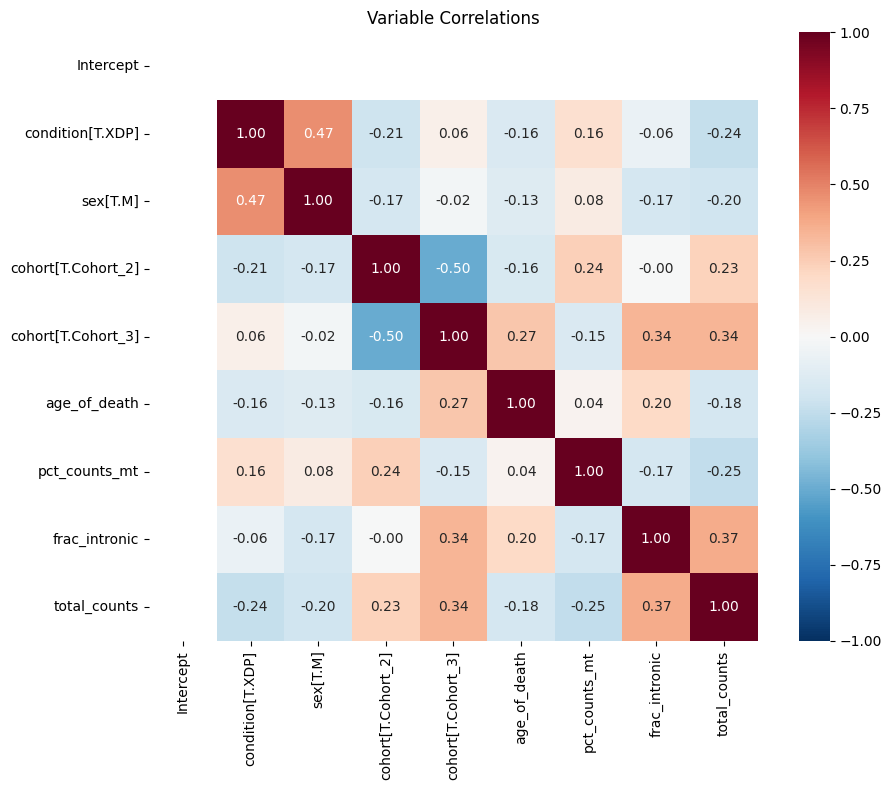

             variable         VIF
0           Intercept  436.010983
4  cohort[T.Cohort_3]    2.334911
8        total_counts    2.102587
3  cohort[T.Cohort_2]    2.090493
1    condition[T.XDP]    1.459381
5        age_of_death    1.379693
7       frac_intronic    1.337330
2            sex[T.M]    1.333336
6       pct_counts_mt    1.266271

binary identifiability test. False
Saving qs file...
	Saving files for R coversion...
	Building R obj...

Setting condition reference level to: Control
Levels: Control XDP 
[1] "Creating Seurat object..."


2026-05-20 12:55:42 | [WARNING] R callback write-console: Warning:  
2026-05-20 12:55:42 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/baseline_nebula/Patch/tmp_Striatum_combined_QC_mmc_ct-cured_zoned_Patch_for_nebula.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/baseline_nebula/Patch/tmp_Striatum_combined_QC_mmc_ct-cured_zoned_Patch_for_nebula.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/baseline_nebula/Patch/tmp_Striatum_combined_QC_mmc_ct-cured_zoned_Patch_for_nebula.qs --id-

In [23]:
for ct in sorted(adata.obs[CT_FOR_DEG_VARIABLE].unique().tolist())[:]:

    #ct="Microglia"
    if ct.startswith("-"):
        continue

    if (TYPE_DEG == "cNMF_nebula") and (ct not in ct_forcNMF[TISSUE]):
        print(f"Skipping {ct} because it's not in the list of cell types to run cNMF on.")
        continue

    print("\n\n######################\n",ct, "\n######################\n")

    # Select single ct
    adata_ct = adata[adata.obs[CT_FOR_DEG_VARIABLE] == ct].to_memory().copy()
    adata_ct.X = adata_ct.layers["counts"].copy() 
    print(np.array_equal(adata_ct.X.data, adata_ct.X.data.astype(int)) if hasattr(adata_ct.X, 'data') else np.array_equal(adata_ct.X, adata_ct.X.astype(int)))

    # adata_ct = adata_ct[adata_ct.obs["zone"].isin(["4"])].copy() # only keep control and XDP for this analsys
    # print(adata_ct)

    # Define saving apthjs
    ADATA_PATH_QS = f"{DEG_FOLDER}/{ct}/tmp_{os.path.splitext(os.path.basename(ADATA_PATH))[0]}_{ct}_for_nebula.qs"
    SAVE_HEALTHY_PCA_RESULT = os.path.dirname(ADATA_PATH_QS)
    os.makedirs(SAVE_HEALTHY_PCA_RESULT, exist_ok=True)
    print(ADATA_PATH_QS)

    #break

    if TYPE_DEG == "cNMF_nebula":
        # For cNMF, we need to provide the spectra file path (with gene names as index)
            # RAW SPECTRA
        matches = glob.glob(f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/{TISSUE}/cNMF_nebula/{ct}/cNMF_run_healthy/*.spectra.*.consensus.txt")
        if len(matches) == 0:
            # First time for this tissue/ct: no spectra yet.
            # run_nebula_with_factors will save healthy_cNMF.h5ad and return None.
            print(f"No spectra found for {ct} — will save healthy h5ad for cNMF training on UGER.")
            CNMF_SPECTRA_PATH = None
        elif len(matches) > 1:
            raise ValueError(f"Expected 1 spectra file for {ct}, found {len(matches)}: {matches}")
        else:
            CNMF_SPECTRA_PATH = matches[0]
    else:
        CNMF_SPECTRA_PATH = None


    # Run enire pipeline for this ct
    nebula_utils.run_nebula_with_factors(
        adata_ct, 
        ADATA_PATH_QS, SAVE_HEALTHY_PCA_RESULT, PARALLEL_NEBULA_SCRIPT_PATH,
        CONTRAST_VARIABLE,CONTRAST_BASELINE, CONTRAST_STIM,
        SAMPLE_VARIABLE,LIBRARY_SIZE_COL,COVARIATES_FOR_DEG,
        N_PCS_TO_USE=None, # default knee method
        variance_threshold=None,delete_tmp_files=True, TYPE_DEG=TYPE_DEG,
        MIN_SAMPLES_PER_CONDITION=4, MIN_NUMBER_GENES_PER_ANALYSIS=3000,
        
        # Attention: spectra file expected to be in fixed place
            #/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/{TISSUE}/cNMF_nebula/{ct}/cNMF_run_healthy/cNMF_spectra.txt
        CNMF_SPECTRA_PATH=CNMF_SPECTRA_PATH
    )

    #break
    

In [12]:
adata.obs[adata.obs[CONTRAST_VARIABLE].isna()][SAMPLE_VARIABLE].unique()

[], Categories (41, object): ['PCMC-16-011', 'PCMC-16-012', 'SCF-18-003', 'SCF-18-004', ..., 'SCF_23_072CF', 'SCF_23_074CF', 'SCF_23_075CM', 'SCF_23_079CF']

# Run for all Zones 
### ONLY STR  --> omly tissue with zones
### cNMF in zone uses the data/files of the cell type used for mapping

In [13]:
if TISSUE != "Striatum":
    exit()

In [14]:
# Map: cell types that have zone analysis → their zone variable
# each cell type has  a better zonation level
ZONE_CT_MAP = {
    "Matrix_D1": "zone", # just zone for zone_6
    "Matrix_D2": "zone",

    "Patch_D1":  "zone_4",
    "Patch_D2":  "zone_4",
    "eMSN_D1D2": "zone_4",
    "Astrocyte": "zone_4",
}
# adata stays untouched here — no more global mutation


In [ ]:
DEG_FOLDER

'/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/SN/cNMF_nebula'

: 

In [ ]:
ZONE_CT_MAP.items()

dict_items([('Matrix_D1', 'zone'), ('Matrix_D2', 'zone'), ('Patch_D1', 'zone_4'), ('Patch_D2', 'zone_4'), ('eMSN_D1D2', 'zone_4'), ('Astrocyte', 'zone_4')])

Using spectra: /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula/Astrocyte/cNMF_run_healthy/healthy_cNMF.spectra.k_12.dt_0_05.consensus.txt


######################
Astrocyte / zone_4=1 / cNMF_nebula
######################

/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula/Astrocyte_by_zone_4/1
True
ATTENTION: .X must be raw!
Retained donors : 47
Filtered genes  : 38601 -> 12878 (min_cells=470, min_counts=50)
Running Factor calculation on Healthy...


/home/gdallagl/myworkdir/XDP/utils/nebula_with_factors.py:461: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


Found existing cNMF spectra at /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula/Astrocyte/cNMF_run_healthy/healthy_cNMF.spectra.k_12.dt_0_05.consensus.txt, skipping cNMF training and proceeding to projection step.
Saved healthy GEP projections: 1977 cells, 11 GEPs
Running Factor calculation on Diseased...
Saved diseased GEP projections: 6112 cells, 11 GEPs
Saving h5ad file...
adata intact: 8089 cells, 12878 genes
ATTENTION: Dropping 0 cells with NaN covariates: []


... storing 'ct_for_deg' as categorical


~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + GEP_1 + GEP_2 + GEP_3 + GEP_4 + GEP_5 + GEP_6 + GEP_7 + GEP_8 + GEP_9 + GEP_10 + GEP_11 + total_counts


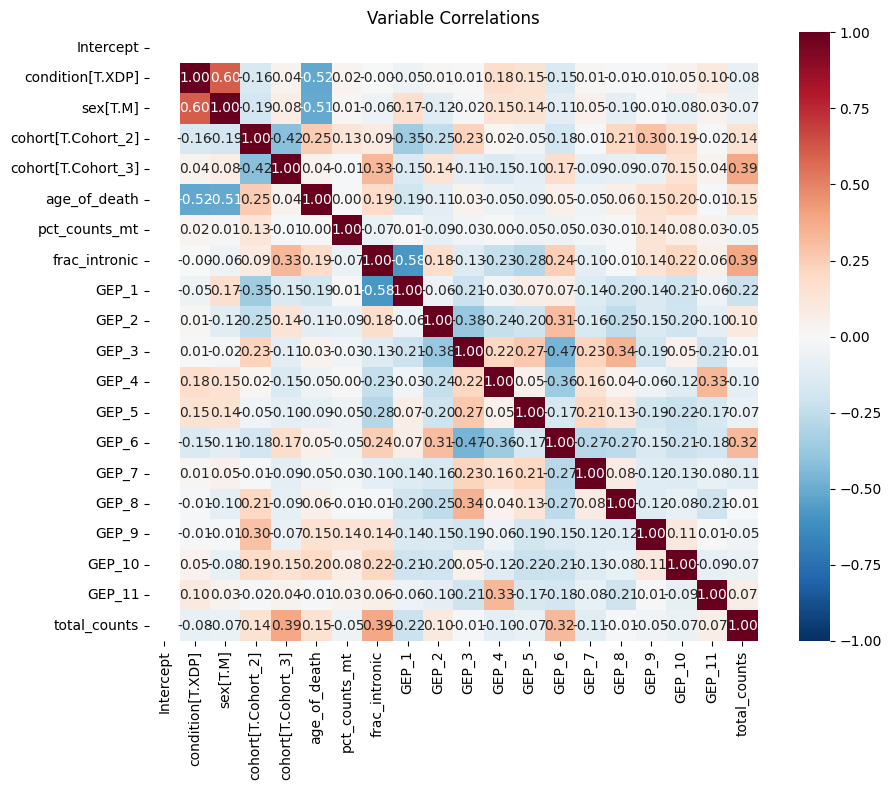

              variable         VIF
0            Intercept  464.954367
13               GEP_6    3.433664
8                GEP_1    2.827076
10               GEP_3    2.700274
17              GEP_10    2.477679
3   cohort[T.Cohort_2]    2.473131
9                GEP_2    2.462106
7        frac_intronic    2.357145
18              GEP_11    2.343027
1     condition[T.XDP]    2.185774
4   cohort[T.Cohort_3]    2.144866
16               GEP_9    2.097945
2             sex[T.M]    2.090622
15               GEP_8    1.930366
19        total_counts    1.824973
5         age_of_death    1.787284
12               GEP_5    1.569213
11               GEP_4    1.568697
14               GEP_7    1.485424
6        pct_counts_mt    1.064202

binary identifiability test. False
ATTENTION: using lmerTest (Gaussian LMM) --> not totally statistically correct (but still robust) 
		 ZIBR coudl be better


2026-04-21 19:28:04 | [WARNING] R callback write-console: condition: factor | example: XDP
  
2026-04-21 19:28:04 | [WARNING] R callback write-console: donor_id: character | example: SCF-20-025
  
2026-04-21 19:28:04 | [WARNING] R callback write-console: age_of_death: numeric | example: 54
  
2026-04-21 19:28:04 | [WARNING] R callback write-console: sex: character | example: M
  
2026-04-21 19:28:04 | [WARNING] R callback write-console: pct_counts_mt: numeric | example: 0.162876852324987
  
2026-04-21 19:28:04 | [WARNING] R callback write-console: frac_intronic: numeric | example: 0.679666889164362
  
2026-04-21 19:28:04 | [WARNING] R callback write-console: cohort: character | example: Cohort_1
  
2026-04-21 19:28:04 | [WARNING] R callback write-console: GEP_1: numeric | example: 0.224756625405671
  
2026-04-21 19:28:04 | [WARNING] R callback write-console: GEP_2: numeric | example: 0.0392135865215256
  
2026-04-21 19:28:04 | [WARNING] R callback write-console: GEP_3: numeric | exampl

factor     beta       se  p_value      fdr
GEP_10 0.098146 0.020377 0.000021 0.000235
 GEP_8 0.060228 0.015796 0.000461 0.002537
 GEP_9 0.065488 0.020323 0.002500 0.008667
 GEP_5 0.033998 0.010854 0.003152 0.008667
 GEP_4 0.022152 0.009326 0.022320 0.048171
 GEP_6 0.041417 0.017977 0.026275 0.048171
 GEP_3 0.046538 0.022976 0.049308 0.077484
GEP_11 0.046749 0.026235 0.082133 0.112933
 GEP_2 0.032440 0.022621 0.159204 0.194582
 GEP_7 0.009721 0.013555 0.477263 0.524990
 GEP_1 0.006494 0.015899 0.685022 0.685022
Significant GEPs (FDR<0.05): ['GEP_10', 'GEP_8', 'GEP_9', 'GEP_5', 'GEP_4', 'GEP_6']
Saving qs file...
	Saving files for R coversion...


2026-04-21 19:28:10 | [WARNING] R callback write-console: Loading required package: SeuratObject
  
2026-04-21 19:28:10 | [WARNING] R callback write-console: Loading required package: sp
  


	Building R obj...


...

[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula/Astrocyte_by_zone_4/1/Striatum_combined_QC_mmc_ct-cured_zoned.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula/Astrocyte_by_zone_4/1/Striatum_combined_QC_mmc_ct-cured_zoned.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula/Astrocyte_by_zone_4/1/Striatum_combined_QC_mmc_ct-cured_zoned.qs --id-col donor_id --offset-col t

/home/gdallagl/myworkdir/XDP/utils/nebula_with_factors.py:461: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


Found existing cNMF spectra at /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula/Astrocyte/cNMF_run_healthy/healthy_cNMF.spectra.k_12.dt_0_05.consensus.txt, skipping cNMF training and proceeding to projection step.
Saved healthy GEP projections: 2668 cells, 11 GEPs
Running Factor calculation on Diseased...
Saved diseased GEP projections: 6765 cells, 11 GEPs
Saving h5ad file...
adata intact: 9433 cells, 13133 genes
ATTENTION: Dropping 0 cells with NaN covariates: []


... storing 'ct_for_deg' as categorical


~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + GEP_1 + GEP_2 + GEP_3 + GEP_4 + GEP_5 + GEP_6 + GEP_7 + GEP_8 + GEP_9 + GEP_10 + GEP_11 + total_counts


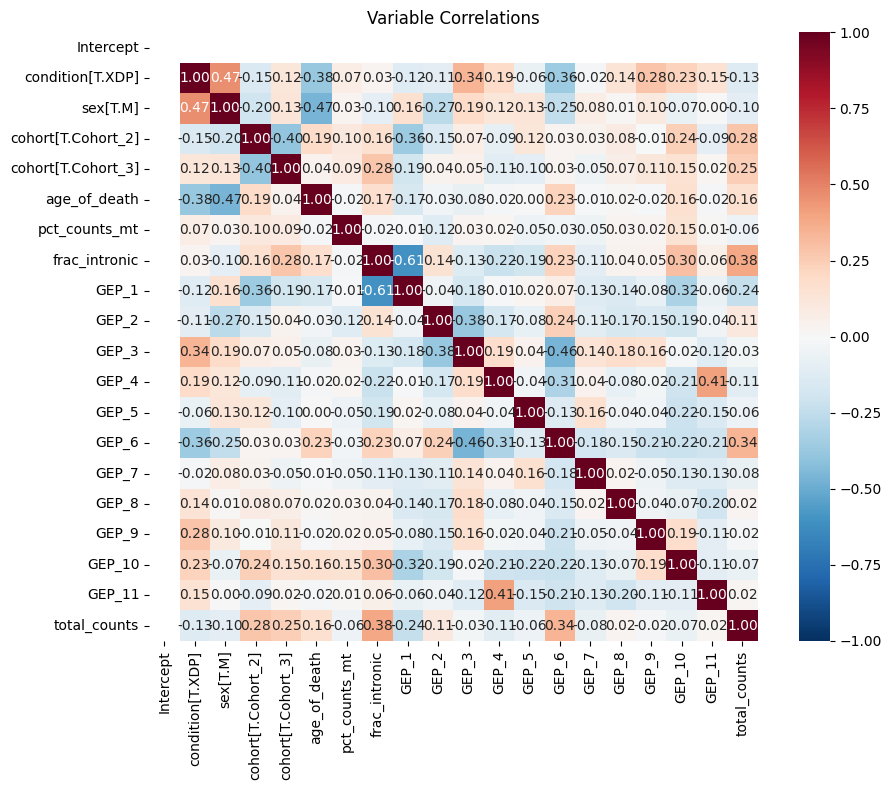

              variable         VIF
0            Intercept  503.198081
17              GEP_10    4.161226
13               GEP_6    3.648289
10               GEP_3    2.916600
8                GEP_1    2.837090
1     condition[T.XDP]    2.831210
18              GEP_11    2.541385
3   cohort[T.Cohort_2]    2.521424
7        frac_intronic    2.397025
9                GEP_2    2.272133
4   cohort[T.Cohort_3]    2.083436
2             sex[T.M]    1.986902
15               GEP_8    1.928329
11               GEP_4    1.788522
19        total_counts    1.773908
5         age_of_death    1.768721
12               GEP_5    1.606974
16               GEP_9    1.440307
14               GEP_7    1.368717
6        pct_counts_mt    1.094718

binary identifiability test. False


2026-04-21 19:31:01 | [WARNING] R callback write-console: condition: factor | example: Control
  
2026-04-21 19:31:01 | [WARNING] R callback write-console: donor_id: character | example: SCF-22-054CM
  
2026-04-21 19:31:01 | [WARNING] R callback write-console: age_of_death: numeric | example: 51
  
2026-04-21 19:31:01 | [WARNING] R callback write-console: sex: character | example: M
  
2026-04-21 19:31:01 | [WARNING] R callback write-console: pct_counts_mt: numeric | example: 0.0280938334035679
  
2026-04-21 19:31:01 | [WARNING] R callback write-console: frac_intronic: numeric | example: 0.738555053838138
  
2026-04-21 19:31:01 | [WARNING] R callback write-console: cohort: character | example: Cohort_1
  
2026-04-21 19:31:01 | [WARNING] R callback write-console: GEP_1: numeric | example: 0.11023022316391
  
2026-04-21 19:31:01 | [WARNING] R callback write-console: GEP_2: numeric | example: 0.070490846427879
  
2026-04-21 19:31:01 | [WARNING] R callback write-console: GEP_3: numeric | e

ATTENTION: using lmerTest (Gaussian LMM) --> not totally statistically correct (but still robust) 
		 ZIBR coudl be better


2026-04-21 19:31:01 | [WARNING] R callback write-console: 
Fitting: GEP_2 ~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + GEP_1 + GEP_3 + GEP_4 + GEP_5 + GEP_6 + GEP_7 + GEP_8 + GEP_9 + GEP_10 + GEP_11 + (1|donor_id)
  
2026-04-21 19:31:01 | [WARNING] R callback write-console: 
Fitting: GEP_3 ~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + GEP_1 + GEP_2 + GEP_4 + GEP_5 + GEP_6 + GEP_7 + GEP_8 + GEP_9 + GEP_10 + GEP_11 + (1|donor_id)
  
2026-04-21 19:31:02 | [WARNING] R callback write-console: 
Fitting: GEP_4 ~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + GEP_1 + GEP_2 + GEP_3 + GEP_5 + GEP_6 + GEP_7 + GEP_8 + GEP_9 + GEP_10 + GEP_11 + (1|donor_id)
  
2026-04-21 19:31:02 | [WARNING] R callback write-console: 
Fitting: GEP_5 ~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + GEP_1 + GEP_2 + GEP_3 + GEP_4 + GEP_6 + GEP_7 + GEP_8 + GEP_9 + GEP_10 + GEP_11 + (1|donor_id)
  
2026-04-

factor     beta       se  p_value      fdr
GEP_10 0.157942 0.028547 0.000002 0.000022
 GEP_8 0.119063 0.023228 0.000008 0.000042
 GEP_9 0.087419 0.019222 0.000048 0.000176
 GEP_3 0.138291 0.031442 0.000076 0.000210
 GEP_4 0.049825 0.012736 0.000342 0.000746
 GEP_6 0.085825 0.022293 0.000407 0.000746
GEP_11 0.092257 0.028580 0.002453 0.003855
 GEP_2 0.068325 0.025480 0.010518 0.014463
 GEP_7 0.043726 0.018728 0.024532 0.029983
 GEP_5 0.042969 0.021042 0.047581 0.052340
 GEP_1 0.035804 0.019163 0.068809 0.068809
Significant GEPs (FDR<0.05): ['GEP_10', 'GEP_8', 'GEP_9', 'GEP_3', 'GEP_4', 'GEP_6', 'GEP_11', 'GEP_2', 'GEP_7']
Saving qs file...
	Saving files for R coversion...
	Building R obj...

Setting condition reference level to: Control
Levels: Control XDP 
[1] "Creating Seurat object..."


...

[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula/Astrocyte_by_zone_4/2/Striatum_combined_QC_mmc_ct-cured_zoned.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula/Astrocyte_by_zone_4/2/Striatum_combined_QC_mmc_ct-cured_zoned.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula/Astrocyte_by_zone_4/2/Striatum_combined_QC_mmc_ct-cured_zoned.qs --id-col donor_id --offset-col t

/home/gdallagl/myworkdir/XDP/utils/nebula_with_factors.py:461: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


Saved healthy GEP projections: 1221 cells, 11 GEPs
Running Factor calculation on Diseased...
Saved diseased GEP projections: 3334 cells, 11 GEPs
Saving h5ad file...
adata intact: 4555 cells, 10693 genes
ATTENTION: Dropping 0 cells with NaN covariates: []


... storing 'ct_for_deg' as categorical


~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + GEP_1 + GEP_2 + GEP_3 + GEP_4 + GEP_5 + GEP_6 + GEP_7 + GEP_8 + GEP_9 + GEP_10 + GEP_11 + total_counts


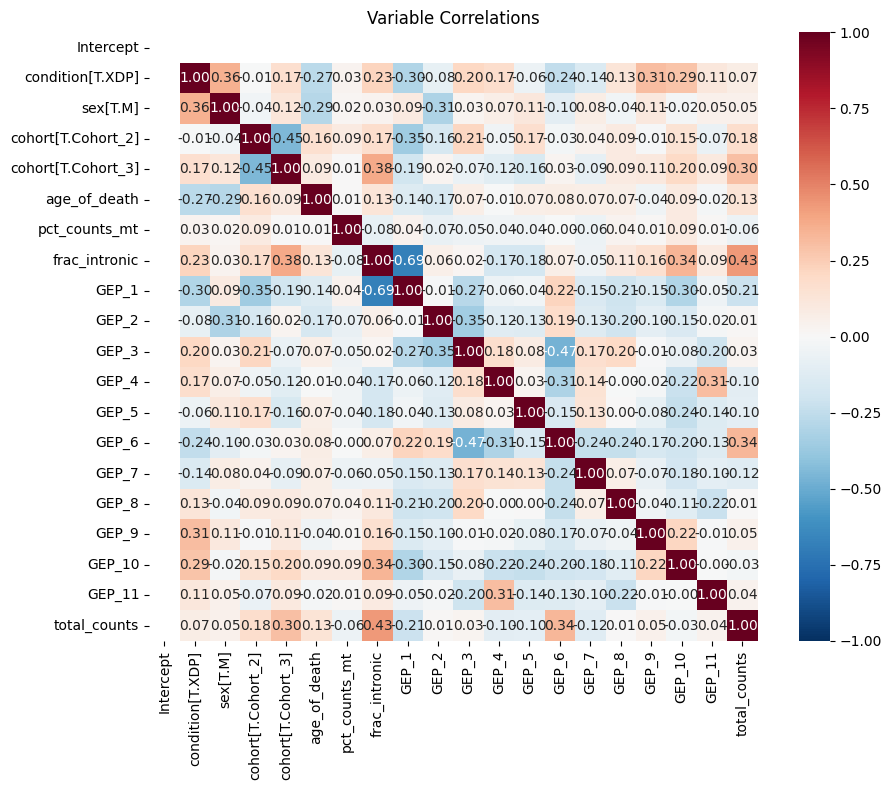

              variable         VIF
0            Intercept  454.428966
8                GEP_1    3.512382
13               GEP_6    3.425556
17              GEP_10    3.287417
7        frac_intronic    3.090422
10               GEP_3    3.036451
3   cohort[T.Cohort_2]    2.419522
4   cohort[T.Cohort_3]    2.316342
9                GEP_2    2.189153
1     condition[T.XDP]    2.146171
15               GEP_8    1.992460
18              GEP_11    1.940032
2             sex[T.M]    1.797399
19        total_counts    1.769930
11               GEP_4    1.618296
12               GEP_5    1.604853
5         age_of_death    1.414939
14               GEP_7    1.398770
16               GEP_9    1.358837
6        pct_counts_mt    1.068489

binary identifiability test. False
ATTENTION: using lmerTest (Gaussian LMM) --> not totally statistically correct (but still robust) 
		 ZIBR coudl be better


2026-04-21 19:34:31 | [WARNING] R callback write-console: condition: factor | example: XDP
  
2026-04-21 19:34:31 | [WARNING] R callback write-console: donor_id: character | example: SCF-20-025
  
2026-04-21 19:34:31 | [WARNING] R callback write-console: age_of_death: numeric | example: 54
  
2026-04-21 19:34:31 | [WARNING] R callback write-console: sex: character | example: M
  
2026-04-21 19:34:31 | [WARNING] R callback write-console: pct_counts_mt: numeric | example: 0.0557931932304259
  
2026-04-21 19:34:31 | [WARNING] R callback write-console: frac_intronic: numeric | example: 0.755158437730287
  
2026-04-21 19:34:31 | [WARNING] R callback write-console: cohort: character | example: Cohort_1
  
2026-04-21 19:34:31 | [WARNING] R callback write-console: GEP_1: numeric | example: 0.0359584308558179
  
2026-04-21 19:34:31 | [WARNING] R callback write-console: GEP_2: numeric | example: 0.0213649584161421
  
2026-04-21 19:34:31 | [WARNING] R callback write-console: GEP_3: numeric | exam

factor     beta       se      p_value          fdr
GEP_10 0.151504 0.022994 7.520151e-08 8.272167e-07
 GEP_8 0.115005 0.020670 2.057815e-06 1.131798e-05
 GEP_9 0.085614 0.016801 8.757385e-06 3.211041e-05
 GEP_3 0.130682 0.028740 4.910388e-05 1.350357e-04
 GEP_4 0.048444 0.011817 2.027215e-04 4.459873e-04
 GEP_6 0.072318 0.021075 1.393152e-03 2.554112e-03
 GEP_2 0.066116 0.022352 5.192771e-03 8.160068e-03
GEP_11 0.073669 0.028356 1.309143e-02 1.800072e-02
 GEP_5 0.042169 0.017131 1.811277e-02 2.213784e-02
 GEP_1 0.019373 0.017016 2.614909e-01 2.876400e-01
 GEP_7 0.011769 0.016703 4.850364e-01 4.850364e-01
Significant GEPs (FDR<0.05): ['GEP_10', 'GEP_8', 'GEP_9', 'GEP_3', 'GEP_4', 'GEP_6', 'GEP_2', 'GEP_11', 'GEP_5']
Saving qs file...
	Saving files for R coversion...
	Building R obj...

Setting condition reference level to: Control
Levels: Control XDP 
[1] "Creating Seurat object..."


2026-04-21 19:34:41 | [WARNING] R callback write-console: Warning:  
2026-04-21 19:34:41 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula/Astrocyte_by_zone_4/3/Striatum_combined_QC_mmc_ct-cured_zoned.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula/Astrocyte_by_zone_4/3/Striatum_combined_QC_mmc_ct-cured_zoned.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula/Astrocyte_by_zone_4/3/Striatum_combined_QC_mmc_ct-cured_zoned.qs --id-col donor_id --offset-col t

/home/gdallagl/myworkdir/XDP/utils/nebula_with_factors.py:461: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


Saved healthy GEP projections: 1312 cells, 11 GEPs
Running Factor calculation on Diseased...
Saved diseased GEP projections: 4280 cells, 11 GEPs
Saving h5ad file...
adata intact: 5592 cells, 10209 genes
ATTENTION: Dropping 0 cells with NaN covariates: []


... storing 'ct_for_deg' as categorical


~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + GEP_1 + GEP_2 + GEP_3 + GEP_4 + GEP_5 + GEP_6 + GEP_7 + GEP_8 + GEP_9 + GEP_10 + GEP_11 + total_counts


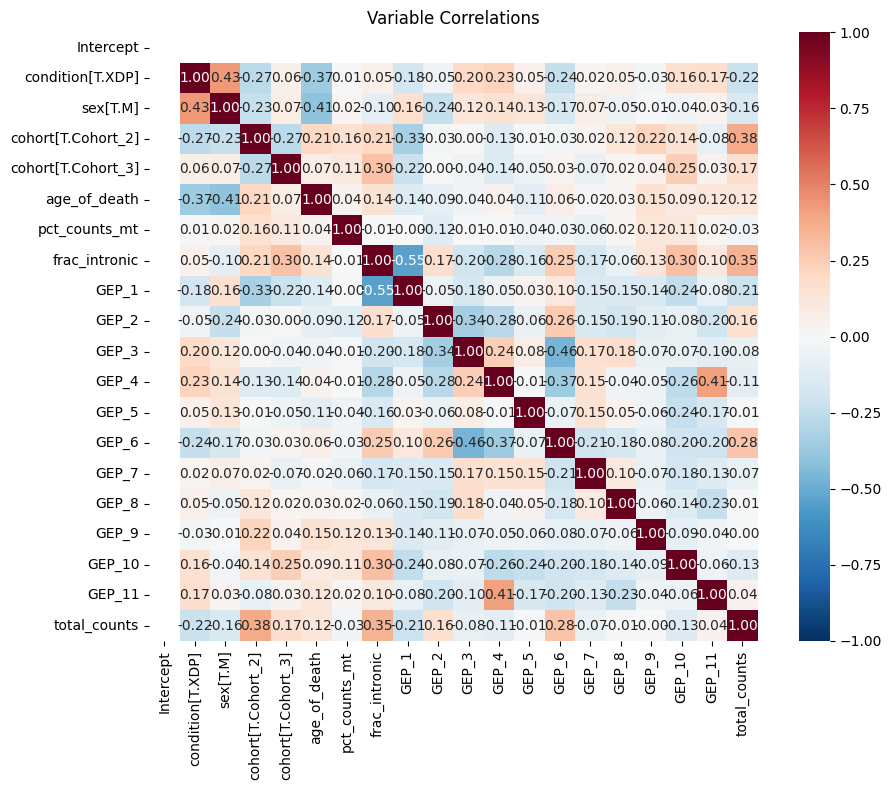

              variable         VIF
0            Intercept  486.673461
17              GEP_10    4.300714
13               GEP_6    3.425875
8                GEP_1    2.885106
18              GEP_11    2.831654
10               GEP_3    2.618694
9                GEP_2    2.539330
3   cohort[T.Cohort_2]    2.436916
7        frac_intronic    2.345063
1     condition[T.XDP]    2.341355
11               GEP_4    2.232498
15               GEP_8    2.212241
16               GEP_9    2.033877
4   cohort[T.Cohort_3]    1.803249
19        total_counts    1.789805
2             sex[T.M]    1.705913
5         age_of_death    1.605347
14               GEP_7    1.602188
12               GEP_5    1.435254
6        pct_counts_mt    1.124203

binary identifiability test. False
ATTENTION: using lmerTest (Gaussian LMM) --> not totally statistically correct (but still robust) 
		 ZIBR coudl be better


2026-04-21 19:36:19 | [WARNING] R callback write-console: condition: factor | example: XDP
  
2026-04-21 19:36:19 | [WARNING] R callback write-console: donor_id: character | example: SCF_22-043
  
2026-04-21 19:36:19 | [WARNING] R callback write-console: age_of_death: numeric | example: 52
  
2026-04-21 19:36:19 | [WARNING] R callback write-console: sex: character | example: M
  
2026-04-21 19:36:19 | [WARNING] R callback write-console: pct_counts_mt: numeric | example: 0.0159438775510204
  
2026-04-21 19:36:19 | [WARNING] R callback write-console: frac_intronic: numeric | example: 0.720992728422384
  
2026-04-21 19:36:19 | [WARNING] R callback write-console: cohort: character | example: Cohort_1
  
2026-04-21 19:36:19 | [WARNING] R callback write-console: GEP_1: numeric | example: 0.101918516763011
  
2026-04-21 19:36:19 | [WARNING] R callback write-console: GEP_2: numeric | example: 0.0134213381600337
  
2026-04-21 19:36:20 | [WARNING] R callback write-console: GEP_3: numeric | examp

factor     beta       se  p_value      fdr
GEP_10 0.152740 0.028352 0.000003 0.000038
 GEP_8 0.113635 0.023620 0.000022 0.000119
 GEP_9 0.105576 0.025091 0.000140 0.000512
 GEP_4 0.058038 0.014428 0.000251 0.000689
 GEP_3 0.116588 0.031431 0.000623 0.001371
 GEP_6 0.076784 0.021235 0.000814 0.001388
 GEP_5 0.059646 0.016629 0.000883 0.001388
 GEP_7 0.058060 0.018049 0.002548 0.003504
GEP_11 0.082627 0.026708 0.003551 0.004340
 GEP_2 0.063327 0.025264 0.016283 0.017911
 GEP_1 0.037170 0.019718 0.066407 0.066407
Significant GEPs (FDR<0.05): ['GEP_10', 'GEP_8', 'GEP_9', 'GEP_4', 'GEP_3', 'GEP_6', 'GEP_5', 'GEP_7', 'GEP_11', 'GEP_2']
Saving qs file...
	Saving files for R coversion...
	Building R obj...

Setting condition reference level to: Control
Levels: Control XDP 
[1] "Creating Seurat object..."


2026-04-21 19:36:30 | [WARNING] R callback write-console: Warning:  
2026-04-21 19:36:30 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula/Astrocyte_by_zone_4/4/Striatum_combined_QC_mmc_ct-cured_zoned.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula/Astrocyte_by_zone_4/4/Striatum_combined_QC_mmc_ct-cured_zoned.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/cNMF_nebula/Astrocyte_by_zone_4/4/Striatum_combined_QC_mmc_ct-cured_zoned.qs --id-col donor_id --offset-col t

: 

In [ ]:
for zone_ct, zone_variable in ZONE_CT_MAP.items():

    # if zone_ct != "Astrocyte":
    #     continue
    
    if zone_ct not in adata.obs["ct_for_deg"].values:
        print(f"WARNING: {zone_ct} not in adata, skipping")
        continue

    # cNMF of celltype_X_zone are not recualted (ie re-facotrize for each zone)
    #  we just use the same cNMF spectra as for the whole cell type, but run Nebula separately for each zone (with the zone as a covariate in the model)
        # Reuse the spectra from the full cell-type cNMF run (already computed)
    if TYPE_DEG == "cNMF_nebula":
        matches = glob.glob(f"{DEG_FOLDER}/{zone_ct}/cNMF_run_healthy/*.spectra.*.consensus.txt")
        if len(matches) != 1:
            print(f"WARNING: Expected 1 spectra file for {zone_ct}, found {len(matches)}: {matches}. Skipping.")
            continue
        CNMF_SPECTRA_PATH = matches[0]
        print(f"Using spectra: {CNMF_SPECTRA_PATH}")
    else:
        CNMF_SPECTRA_PATH = None

    adata_zone = adata[
        (adata.obs["ct_for_deg"] == zone_ct) & # filter to QC labels
        (adata.obs[zone_variable].notna()) # only cells with zone annotation
    ].to_memory().copy()

    for zone in sorted(adata_zone.obs[zone_variable].unique()):
        print(f"\n\n######################\n{zone_ct} / {zone_variable}={zone} / {TYPE_DEG}\n######################\n")

        adata_ct = adata_zone[adata_zone.obs[zone_variable] == zone].to_memory().copy()
        adata_ct.X = adata_ct.layers["counts"].copy()

        subfolder = f"{zone_ct}_by_{zone_variable}/{zone}"
        ADATA_PATH_QS = f"{DEG_FOLDER}/{subfolder}/{os.path.splitext(os.path.basename(ADATA_PATH))[0]}.qs"
        SAVE_HEALTHY_PCA_RESULT = os.path.dirname(ADATA_PATH_QS)
        os.makedirs(SAVE_HEALTHY_PCA_RESULT, exist_ok=True)
        print(SAVE_HEALTHY_PCA_RESULT)

        nebula_utils.run_nebula_with_factors(
            adata_ct,
            ADATA_PATH_QS, SAVE_HEALTHY_PCA_RESULT, PARALLEL_NEBULA_SCRIPT_PATH,
            CONTRAST_VARIABLE, CONTRAST_BASELINE, CONTRAST_STIM,
            SAMPLE_VARIABLE, LIBRARY_SIZE_COL, COVARIATES_FOR_DEG,
            N_PCS_TO_USE=None, variance_threshold=None, delete_tmp_files=True, TYPE_DEG=TYPE_DEG,
            MIN_SAMPLES_PER_CONDITION=4, MIN_NUMBER_GENES_PER_ANALYSIS=3000,
            CNMF_SPECTRA_PATH=CNMF_SPECTRA_PATH
        )


    #break


#

# ---

### NUP

In [5]:
adata_nn = adata[adata.obs["ct_for_deg"] == "Matrix"].copy()

In [27]:
from utils import label_mapping_utils as lmu

nup_genesets = {

    # # NPC structural — Y-complex scaffold
    # # Co-assembled outer ring, biologically motivated grouping
    # "nup_y_complex": [
    #     "NUP107", "NUP133", "NUP160", "NUP85", "NUP37", "NUP43", "SEH1L", "SEC13"
    # ],

    # # NPC structural — inner ring
    # # Most structurally constrained, should be tightly co-expressed
    # "nup_inner_ring": [
    #     "NUP155", "NUP93", "NUP188", "NUP205", "NUP35"
    # ],

    # NPC structural — combined scaffold (Y-complex + inner ring)
    # Use this as the primary NPC integrity score
    "nup_scaffold": [
        "NUP107", "NUP133", "NUP160", "NUP85", "NUP37", "NUP43", "SEH1L", "SEC13",
        "NUP155", "NUP93", "NUP188", "NUP205", "NUP35"
    ],

    # # FG nucleoporins — central channel and cytoplasmic face
    # # Score separately — regulatory roles beyond structure
    # "nup_fg": [
    #     "NUP62", "NUP58", "NUP54", "NUP98", "NUP88", "NUP214",
    #     "NUP153", "NUP50", "RANBP2", "NUP42", "NUP210"
    # ],

    # # Transmembrane anchors — all trending DOWN in XDP
    # # Score separately — opposite direction to scaffold
    # "nup_transmembrane": [
    #     "NDC1", "POM121", "POM121C"
    # ],

    # # Nuclear basket
    # "nup_basket": [
    #     "TPR", "RAE1", "NUP153", "NUP50"
    # ],

    # DEG-significant upregulated NUPs only (p<0.05 in your data)
    # Statistically motivated but partially circular — use with caution
    "nup_deg_up": [
        "NUP155", "NUP58", "NUP160", "NUP88", "NUP54", "NUP93",
        "NUP37", "NUP153", "NUP50", "RANBP2", "TPR", "RAE1"
    ],

    # # DEG-significant downregulated NUPs (p<0.05 in your data)
    # # Score separately — opposite direction
    # # High score here = MORE disrupted
    # "nup_deg_down": [
    #     "RCC1", "NDC1", "KPNA2", "PHAX"
    # ],

    # # RAN GTPase cycle — the gradient machinery
    # "ran_system": [
    #     "RAN", "RCC1", "RANGAP1", "RANBP1", "RANBP2",
    #     "RANBP3", "RANBP6", "RANBP9", "RANBP10", "NUTF2"
    # ],

    # # RAN gradient disruption — mechanistic 2-gene score
    # # Interpret inverted: high score = disrupted gradient
    # # Use -RCC1 + RANGAP1 logic manually after scoring
    # "ran_disruption": [
    #     "RCC1", "RANGAP1", "NUTF2"
    # ],

    # # Importin-alpha family
    # "importin_alpha": [
    #     "KPNA1", "KPNA2", "KPNA3", "KPNA4", "KPNA5", "KPNA6", "KPNA7"
    # ],

    # # Importin-beta family (direct import receptors)
    # "importin_beta": [
    #     "KPNB1", "IPO4", "IPO5", "IPO7", "IPO8", "IPO9", "IPO11", "IPO13",
    #     "TNPO1", "TNPO2", "TNPO3", "SNUPN"
    # ],

    # # Exportins
    # "exportins": [
    #     "XPO1", "XPO2", "XPO4", "XPO5", "XPO6", "XPO7", "CSE1L", "PHAX"
    # ],

    # # mRNA export — TREX/NXF1 pathway
    # "mrna_export": [
    #     "NXF1", "NXT1", "ALYREF",
    #     "THOC1", "THOC2", "THOC5", "THOC6", "THOC7",
    #     "DDX19A", "DDX19B", "GLE1", "RAE1"
    # ],

    # Full nuclear transport — everything together
    # Use only for exploratory overview, too broad for mechanistic claims
    "nuclear_transport_all": [
        "NUP107", "NUP133", "NUP160", "NUP85", "NUP37", "NUP43", "SEH1L", "SEC13",
        "NUP155", "NUP93", "NUP188", "NUP205", "NUP35",
        "NUP62", "NUP58", "NUP54", "NUP98", "NUP88", "NUP214",
        "NUP153", "NUP50", "RANBP2",
        "NDC1", "POM121", "POM121C",
        "TPR", "RAE1",
        "RAN", "RCC1", "RANGAP1", "NUTF2",
        "KPNB1", "IPO5", "IPO9", "IPO11", "TNPO1",
        "XPO1", "XPO4", "XPO5",
        "NXF1", "NXT1", "THOC1", "THOC2", "THOC7", "GLE1"
    ],

    # Recommended primary score for XDP analysis
    # Biologically motivated, directionally coherent, not circular
    "nup_primary": [
        "NUP155", "NUP160", "NUP54", "NUP88", "NUP58",
        "NUP37", "NUP35", "TPR", "RAE1", "RANBP2"
    ],

}

for score_name, genes in nup_genesets.items():
    print(f"Calculating score: {score_name} with {len(genes)} genes.")
    lmu.aucell(adata_nn, genes, score_name)

Calculating score: nup_scaffold with 13 genes.
Mapped 13/13 genes for nup_scaffold
Calculating score: nup_deg_up with 12 genes.
Mapped 12/12 genes for nup_deg_up
Calculating score: nuclear_transport_all with 45 genes.
Mapped 45/45 genes for nuclear_transport_all
Calculating score: nup_primary with 10 genes.
Mapped 10/10 genes for nup_primary


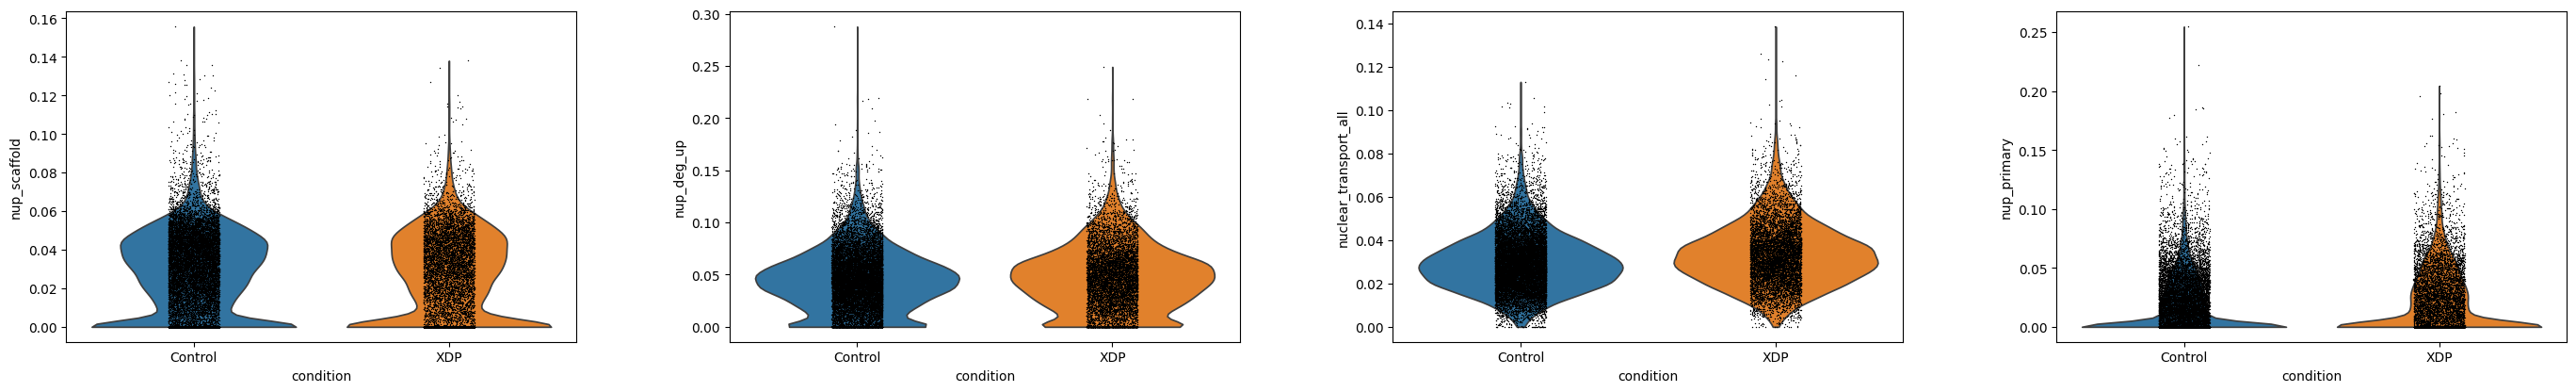

In [28]:
sc.pl.violin(adata_nn, keys=list(nup_genesets.keys()), groupby='condition')

/tmp/ipykernel_2990247/1033659324.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['donor_id', 'condition'])  # add your covariates


,donor_id,condition,nup_deg_up,nuclear_transport_all,nup_primary
1,PCMC-16-011,XDP,0.052874,0.039903,0.024042
3,PCMC-16-012,XDP,0.066345,0.038357,0.039868
5,SCF-18-003,XDP,0.036414,0.030945,0.009650
7,SCF-18-004,XDP,0.046851,0.034868,0.024841
9,SCF-18-006,XDP,0.044828,0.032108,0.023490
11,SCF-19-009,XDP,0.044138,0.039631,0.017094
13,SCF-19-014,XDP,0.045057,0.036439,0.023518
15,SCF-19-018,XDP,0.044322,0.036860,0.015440
17,SCF-19-020,XDP,0.040874,0.029448,0.005128
19,SCF-20-023,XDP,0.052000,0.032999,0.022112


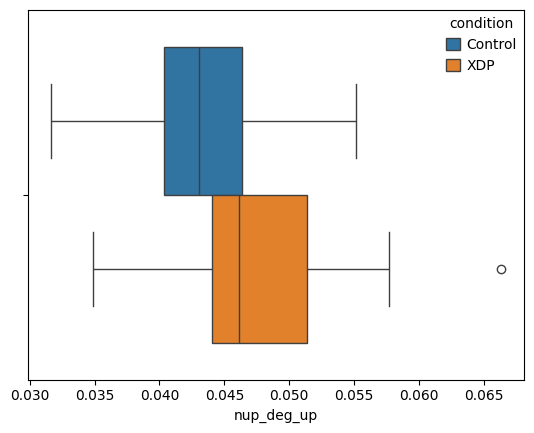

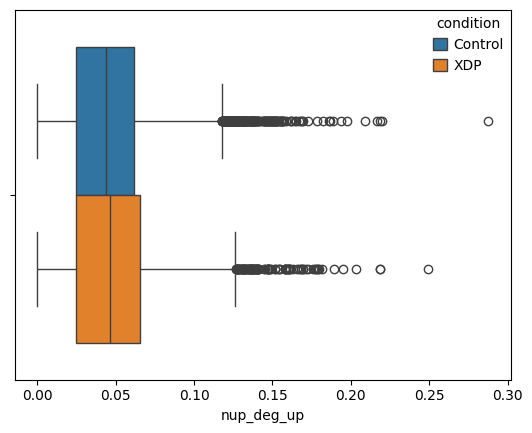

/tmp/ipykernel_2990247/1033659324.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['donor_id', 'condition', 'zone'])  # add your covariates


,donor_id,condition,zone,nup_deg_up,nuclear_transport_all,nup_primary
7,PCMC-16-011,XDP,2,0.098391,0.039730,0.051172
8,PCMC-16-011,XDP,3,0.044897,0.042378,0.014227
9,PCMC-16-011,XDP,4,0.036828,0.034694,0.021340
10,PCMC-16-011,XDP,5,0.043218,0.040139,0.023601
11,PCMC-16-011,XDP,6,0.063264,0.041178,0.032037
...,...,...,...,...,...,...
553,SCF_23_079CF,Control,2,0.035448,0.030450,0.003750
554,SCF_23_079CF,Control,3,0.037839,0.028582,0.006341
555,SCF_23_079CF,Control,4,0.033931,0.024684,0.000717
556,SCF_23_079CF,Control,5,0.047747,0.041704,0.026468




Zone: 5



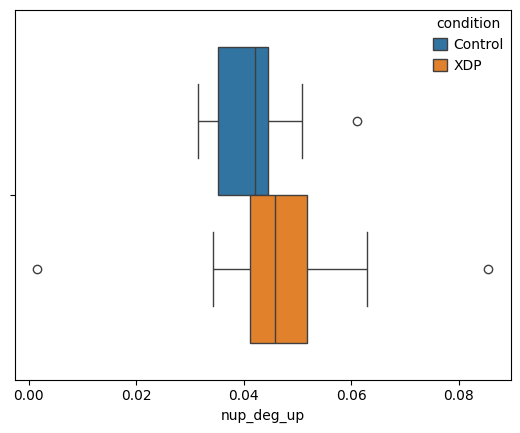

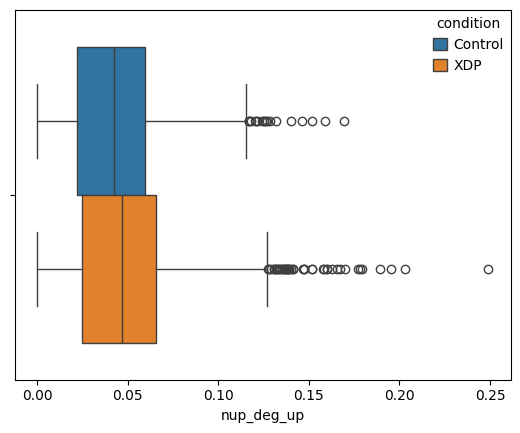



Zone: 6



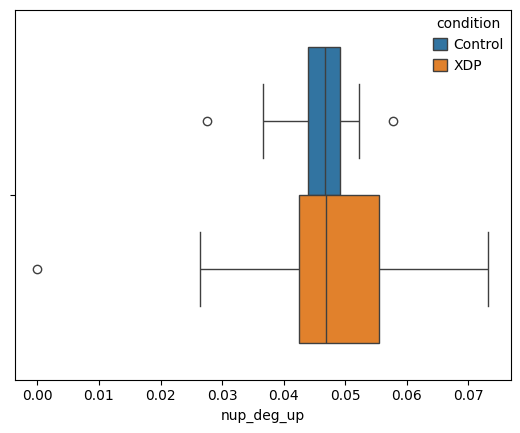

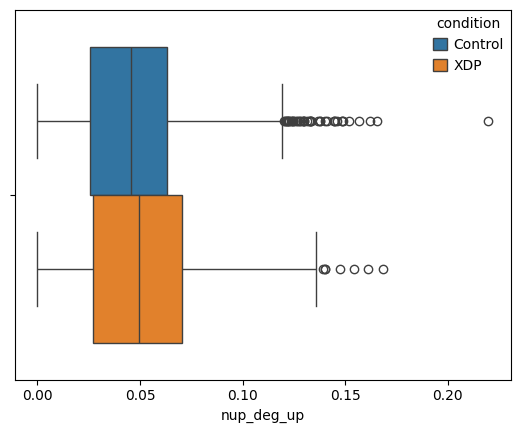



Zone: 4



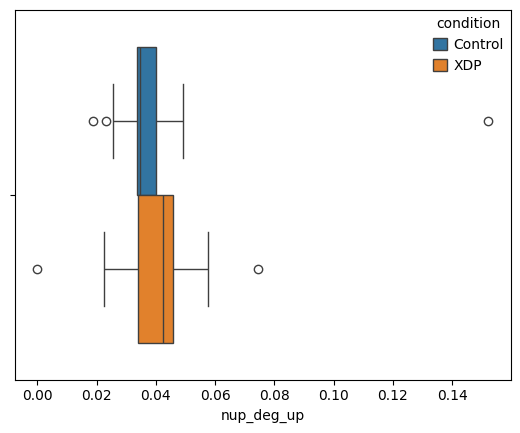

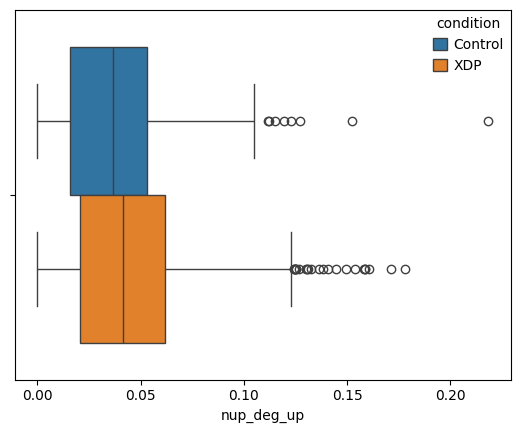



Zone: 3



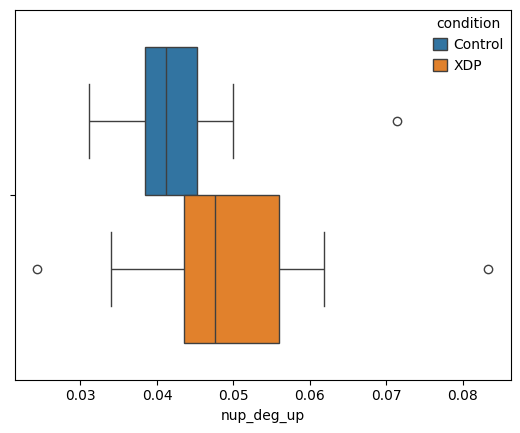

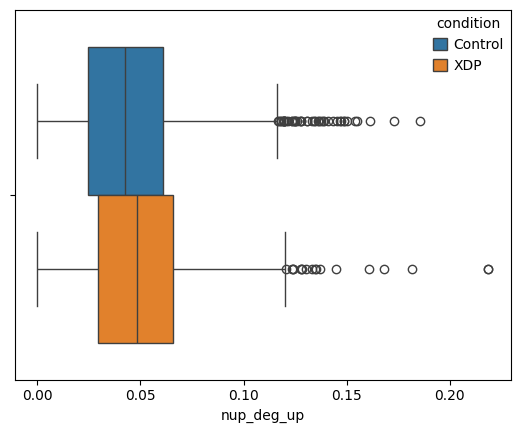



Zone: 1



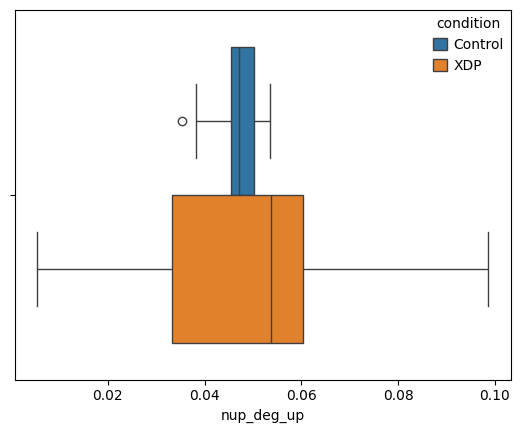

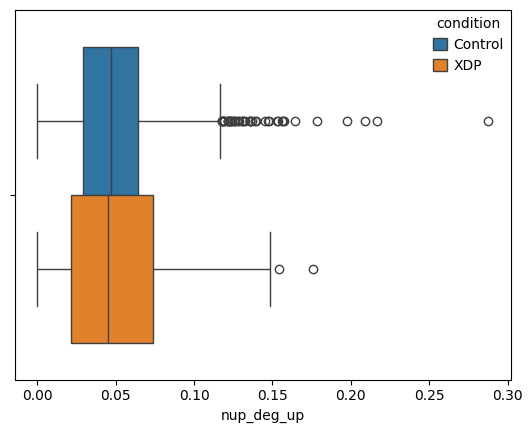



Zone: 2



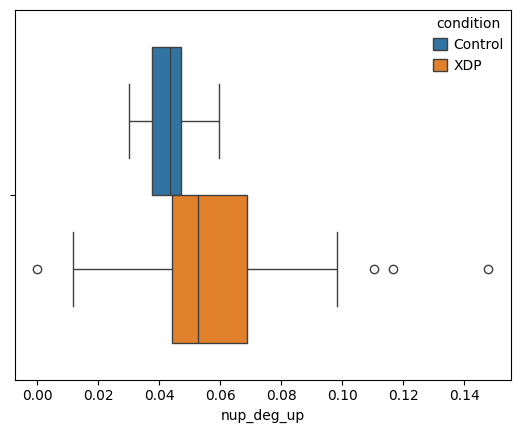

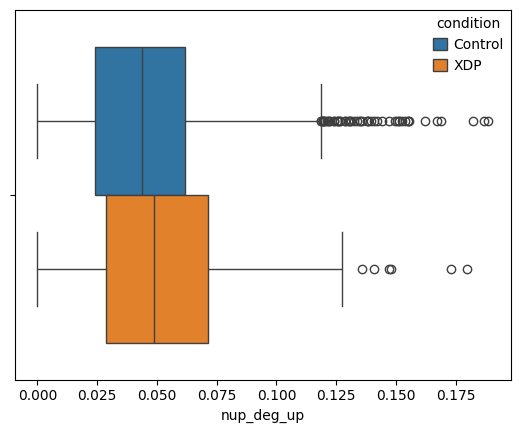

/tmp/ipykernel_2990247/1033659324.py:36: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = mannwhitneyu(xdp, ctrl, alternative='greater')


(np.float64(nan), np.float64(nan))

In [26]:
col = "nup_deg_up"

pseudobulk = (
    adata_nn.obs
    .groupby(['donor_id', 'condition'])  # add your covariates
    [list(nup_genesets.keys())]                                  # the score columns
    .median()                                                     # median is more robust than mean
    .reset_index()
)
pseudobulk = pseudobulk.dropna(subset=[col])  # drop samples with missing scores
display(pseudobulk)

from scipy.stats import mannwhitneyu
sns.boxplot(data=pseudobulk, x=col, hue="condition"); plt.show()
sns.boxplot(data=adata_nn.obs, x=col, hue="condition"); plt.show()


pseudobulk = (
    adata_nn.obs
    .groupby(['donor_id', 'condition', 'zone'])  # add your covariates
    [list(nup_genesets.keys())]                                  # the score columns
    .median()                                                     # median is more robust than mean
    .reset_index()
)
pseudobulk = pseudobulk.dropna(subset=[col])  # drop samples with missing scores
display(pseudobulk)
for zone in adata_nn.obs["zone"].dropna().unique():
    print(f"\n\nZone: {zone}\n")
    adata_ct = adata_nn[adata_nn.obs["zone"] == zone].to_memory().copy()
    pseudobulk_zone = pseudobulk[pseudobulk["zone"] == zone]
    sns.boxplot(data=pseudobulk_zone, x=col, hue="condition"); plt.show()
    sns.boxplot(data=adata_ct.obs, x=col, hue="condition"); plt.show()

xdp = pseudobulk[pseudobulk['condition'] == 'XDP'][col]
ctrl = pseudobulk[pseudobulk['condition'] == 'control'][col]
stat, p = mannwhitneyu(xdp, ctrl, alternative='greater')
stat, p